# LightGCN Ranking Model — Hotel Recommender


**Task**: predict the next hotel a user will visit (leave-last-out: for each user, the most recent interaction is held out as test, the second-most-recent as validation).

**Primary metric: NDCG@10** — rewards ranking the correct next hotel higher in the list. A correct prediction at position 1 counts more than at position 10, which matches the practical goal of showing the user a short ranked list.

**Secondary metric: HR@10** — coarser "did we get it in the top 10 at all" check. Useful for sanity but less informative about ranking quality.


## 1. Configuration

All hyperparameters and paths in one place. Defaults follow the LightGCN paper for medium-scale datasets.


In [3]:
import os

# ── Paths ──────────────────────────────────────────────────────
INPUT_DIR  = "phase1_outputs"
OUTPUT_DIR = "phase2_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_FILE = os.path.join(INPUT_DIR, "interactions_model_ready_train.parquet")
VALID_FILE = os.path.join(INPUT_DIR, "interactions_model_ready_valid.parquet")
TEST_FILE  = os.path.join(INPUT_DIR, "interactions_model_ready_test.parquet")

# ── Model hyperparameters (defaults; sweep may override) ───────
EMBED_DIM   = 64        
NUM_LAYERS  = 2          
LR          = 0.001      
L2_REG      = .0001      

# ── Training ───────────────────────────────────────────────────
BATCH_SIZE      = 4_096   
EPOCHS          = 1000       # Early stopping will cut short
PATIENCE        = 10         
MAX_STEPS_EPOCH = 200        

# ── AMP / speed ────────────────────────────────────────────────
USE_AMP = True               # BF16 autocast on modern NVIDIA GPUs

# ── Evaluation ─────────────────────────────────────────────────
TOP_K_LIST = [1, 5, 10, 20]
PRIMARY_METRIC   = "NDCG@10"
SECONDARY_METRIC = "HR@10"

VALID_EVAL_USERS = 50_000
TEST_EVAL_USERS  = 25_000
SWEEP_EVAL_USERS = 5_000     # Smaller during sweep; final run uses larger eval

EVAL_EVERY = 1
EVAL_CHUNK = 4096            # Larger chunks should fit on a 5090

# ── Hyperparameter sweep ───────────────────────────────────────
RUN_SWEEP              = False           # Set False to skip sweep and use defaults above
SWEEP_TIME_BUDGET_SEC  = 2 * 60 * 60    # 2-hour budget
SWEEP_EPOCHS_PER_TRIAL = 10              # Enough to separate promising configs
SWEEP_MAX_TRIALS       = 10              # Upper bound; may stop earlier on time
SWEEP_STEPS_PER_EPOCH  = 50             # Comparable signal to final training

# Random search space — draws without replacement from these lists per trial
SWEEP_SPACE = {
    "lr":         [1e-3, 3e-3, 5e-3, 1e-2],
    "l2_reg":     [1e-5, 5e-5, 1e-4],
    "num_layers": [2, 3]
}

# ── Reproducibility ────────────────────────────────────────────
SEED = 42

# ── Output artifacts (saved to phase2_outputs/) ────────────────
CHECKPOINT_FILE    = os.path.join(OUTPUT_DIR, "lightgcn_best.pt")
VALID_SAMPLE_FILE  = os.path.join(OUTPUT_DIR, "lightgcn_valid_eval_users.npy")
TEST_SAMPLE_FILE   = os.path.join(OUTPUT_DIR, "lightgcn_test_eval_users.npy")
SWEEP_RESULTS_FILE = os.path.join(OUTPUT_DIR, "lightgcn_sweep_results.csv")
BEST_CONFIG_FILE   = os.path.join(OUTPUT_DIR, "lightgcn_best_config.json")


## 2. Imports and device setup

In [4]:
import time
import math
import json
import random
import contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.nn.models import LightGCN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

def amp_ctx():
    """Autocast context if USE_AMP, otherwise a no-op.

    BF16 is chosen deliberately — same dynamic range as FP32, so no loss-scaler
    needed, and 5090/Ada/Hopper tensor cores hit full throughput on BF16.
    """
    if USE_AMP:
        return torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16)
    return contextlib.nullcontext()

print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU:    {torch.cuda.get_device_name(0)}")
    print(f"VRAM:   {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"AMP:    {'BF16' if USE_AMP else 'off'}")

Device: cuda
GPU:    NVIDIA GeForce RTX 5090
VRAM:   31.8 GB
AMP:    BF16


## 3. Load splits

We load only the columns we need. The parquet files come from the pipeline notebook and have already been deduplicated, 5-core filtered, temporally split leave-last-out per user, and ID-mapped to contiguous integers.

Using `max(train, valid, test)` for `n_users` and `n_items` makes the node namespace safe even if valid or test contains IDs outside the train range. Only train-known items will be *rankable* (enforced below) — this matches the popularity baseline, which can only rank items it has popularity scores for.


In [5]:
train_df = pd.read_parquet(TRAIN_FILE, columns=["user_idx", "item_idx", "rating"])
valid_df = pd.read_parquet(VALID_FILE, columns=["user_idx", "item_idx", "rating"])
test_df  = pd.read_parquet(TEST_FILE,  columns=["user_idx", "item_idx", "rating"])

# Global max across splits, so the node namespace never excludes a valid/test ID
n_users = int(max(
    train_df["user_idx"].max(),
    valid_df["user_idx"].max(),
    test_df["user_idx"].max(),
)) + 1
n_items = int(max(
    train_df["item_idx"].max(),
    valid_df["item_idx"].max(),
    test_df["item_idx"].max(),
)) + 1
n_nodes = n_users + n_items

print(f"Global users:  {n_users:,}")
print(f"Global items:  {n_items:,}")
print(f"Total nodes:   {n_nodes:,}")
print(f"Train rows:    {len(train_df):,}")
print(f"Valid rows:    {len(valid_df):,}")
print(f"Test rows:     {len(test_df):,}")

print("\nUnique users per split (leave-last-out should give one row per user):")
print(f"  train: {train_df['user_idx'].nunique():,}")
print(f"  valid: {valid_df['user_idx'].nunique():,}")
print(f"  test : {test_df['user_idx'].nunique():,}")


Global users:  1,927,834
Global items:  309,904
Total nodes:   2,237,738
Train rows:    16,064,988
Valid rows:    1,927,834
Test rows:     1,927,834

Unique users per split (leave-last-out should give one row per user):
  train: 1,927,834
  valid: 1,927,834
  test : 1,927,834


## 5. Build the bipartite graph

LightGCN operates on an undirected graph where users and items are both nodes. We give items node IDs offset by `n_users` so all nodes live in one flat namespace:
- users occupy indices `[0, n_users)`
- items occupy indices `[n_users, n_users + n_items)`

PyG's LightGCN expects an undirected edge index with both directions stored explicitly.

`rankable_items` is the set of items that appeared in train. Only these can be recommended at inference — matching the popularity baseline's candidate universe.


In [6]:
train_users_np = train_df["user_idx"].to_numpy(dtype=np.int64)
train_items_np = train_df["item_idx"].to_numpy(dtype=np.int64)

# Rankable item universe = items that appear in TRAIN
train_user_set = set(train_df["user_idx"].unique().tolist())
train_item_set = set(train_df["item_idx"].unique().tolist())

rankable_items_np = np.array(sorted(train_item_set), dtype=np.int64)
rankable_items_t  = torch.tensor(rankable_items_np, dtype=torch.long, device=device)

# item_idx -> local position inside rankable_items_np, for fast masking
rankable_item_pos = {int(item): pos for pos, item in enumerate(rankable_items_np)}

print(f"Train users in graph:   {len(train_user_set):,}")
print(f"Train items in graph:   {len(train_item_set):,}")
print(f"Rankable items:         {len(rankable_items_np):,}")

# Build bidirectional bipartite edges
src = np.concatenate([train_users_np, train_items_np + n_users])
dst = np.concatenate([train_items_np + n_users, train_users_np])
edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long, device=device)

print(f"\nEdge index shape: {tuple(edge_index.shape)}")
print(f"Directed edges:   {edge_index.shape[1]:,} (2 x n_interactions)")


Train users in graph:   1,927,834
Train items in graph:   309,395
Rankable items:         309,395

Edge index shape: (2, 32129976)
Directed edges:   32,129,976 (2 x n_interactions)


## 6. Precompute lookup structures


In [7]:
# Full train interactions per user — used as positives for BPR sampling
# and as seen items for validation eval masking.
train_seen_by_user = train_df.groupby("user_idx")["item_idx"].agg(set).to_dict()

# For test eval, also mask items seen in valid
train_valid_df = pd.concat(
    [train_df[["user_idx", "item_idx"]], valid_df[["user_idx", "item_idx"]]],
    ignore_index=True,
)
train_valid_seen_by_user = train_valid_df.groupby("user_idx")["item_idx"].agg(set).to_dict()

def build_seen_positions(seen_by_user, rankable_item_pos):
    """Convert seen item_idx values to their positions in rankable_items_np
    for fast masking during evaluation."""
    out = {}
    for u, items in seen_by_user.items():
        pos_list = [rankable_item_pos[i] for i in items if i in rankable_item_pos]
        if pos_list:
            out[int(u)] = np.array(pos_list, dtype=np.int64)
    return out

train_seen_pos_by_user       = build_seen_positions(train_seen_by_user, rankable_item_pos)
train_valid_seen_pos_by_user = build_seen_positions(train_valid_seen_by_user, rankable_item_pos)

# BPR positive lookup: all observed train interactions
train_user_pos = train_seen_by_user

print(f"Users with train history:       {len(train_seen_by_user):,}")
print(f"Users with train+valid history: {len(train_valid_seen_by_user):,}")


Users with train history:       1,927,834
Users with train+valid history: 1,927,834


## 7. Build evaluation targets (warm-start filter)


In [8]:
def build_eval_targets(eval_df, split_name, sample_users=None):
    tmp = eval_df[["user_idx", "item_idx"]].copy()

    # Leave-last-out should give exactly one target per user
    dup_counts = tmp.groupby("user_idx").size()
    if int(dup_counts.max()) != 1:
        raise ValueError(f"{split_name} split has users with more than one row.")

    total_rows = len(tmp)

    # Warm-start filter: both user AND target item must exist in train
    warm_mask = (
        tmp["user_idx"].isin(train_user_set) &
        tmp["item_idx"].isin(train_item_set)
    )
    warm_df    = tmp[warm_mask]
    dropped_df = tmp[~warm_mask]

    target_by_user = dict(zip(
        warm_df["user_idx"].astype(int),
        warm_df["item_idx"].astype(int),
    ))
    eval_users = np.array(sorted(target_by_user.keys()), dtype=np.int64)

    # Optional deterministic sampling
    if sample_users is not None and len(eval_users) > sample_users:
        rng = np.random.default_rng(SEED)
        eval_users = np.sort(rng.choice(eval_users, size=sample_users, replace=False))

    target_by_user = {int(u): int(target_by_user[int(u)]) for u in eval_users.tolist()}

    stats = {
        "split_name": split_name,
        "total_targets": int(total_rows),
        "warm_start_targets": int(len(warm_df)),
        "dropped_cold_targets": int(len(dropped_df)),
        "warm_start_pct": float(100.0 * len(warm_df) / total_rows) if total_rows else 0.0,
        "users_used_after_sampling": int(len(eval_users)),
    }
    return target_by_user, eval_users.tolist(), stats


valid_target_by_user, valid_users, valid_stats = build_eval_targets(
    valid_df, split_name="valid", sample_users=VALID_EVAL_USERS
)
test_target_by_user, test_users, test_stats = build_eval_targets(
    test_df, split_name="test", sample_users=TEST_EVAL_USERS
)

print("Evaluation target coverage")
print("-" * 60)
for stats in [valid_stats, test_stats]:
    print(f"{stats['split_name'].upper()}:")
    print(f"  total targets:              {stats['total_targets']:,}")
    print(f"  warm-start targets kept:    {stats['warm_start_targets']:,}")
    print(f"  dropped cold-start targets: {stats['dropped_cold_targets']:,}")
    print(f"  warm-start percent kept:    {stats['warm_start_pct']:.2f}%")
    print(f"  users used in this run:     {stats['users_used_after_sampling']:,}")
    print()

# Persist sampled user IDs for cross-notebook consistency
np.save(VALID_SAMPLE_FILE, np.array(valid_users, dtype=np.int64))
np.save(TEST_SAMPLE_FILE,  np.array(test_users,  dtype=np.int64))
print(f"Saved sampled valid users → {VALID_SAMPLE_FILE}")
print(f"Saved sampled test users  → {TEST_SAMPLE_FILE}")
print("Use these .npy files in the popularity and MF notebooks for identical-user evaluation.")


Evaluation target coverage
------------------------------------------------------------
VALID:
  total targets:              1,927,834
  warm-start targets kept:    1,926,837
  dropped cold-start targets: 997
  warm-start percent kept:    99.95%
  users used in this run:     50,000

TEST:
  total targets:              1,927,834
  warm-start targets kept:    1,925,376
  dropped cold-start targets: 2,458
  warm-start percent kept:    99.87%
  users used in this run:     25,000

Saved sampled valid users → phase2_outputs\lightgcn_valid_eval_users.npy
Saved sampled test users  → phase2_outputs\lightgcn_test_eval_users.npy
Use these .npy files in the popularity and MF notebooks for identical-user evaluation.


## 8. BPR triplet sampler

For each training step we draw `BATCH_SIZE` triplets `(user, pos_item, neg_item)`:
- `user` and `pos_item` come from a random train interaction
- `neg_item` is drawn uniformly from rankable items, rejecting any the user already interacted with


In [9]:
# Precompute interactions on-device so sampling stays on GPU.
_train_users_gpu = torch.from_numpy(train_users_np).to(device)
_train_items_gpu = torch.from_numpy(train_items_np).to(device)
# rankable_items_t is already on device from the graph-build cell above.

def sample_bpr_triplets(batch_size):
    """Vectorized BPR sampling — all on GPU, zero Python loop.

    We sample negatives uniformly from rankable items WITHOUT rejecting
    the user's own positives. With ~8 positives per user out of ~309k items,
    the expected false-negative rate is ~0.003% per triplet. That adds a
    negligible amount of noise to BPR gradients and removes what was the
    largest CPU bottleneck in the old sampler (a 65k-iteration Python
    `while ... in pos_set:` loop per step).

    This is standard practice in large-scale BPR / graph-recsys code —
    the noise disappears under the much larger signal from 2-3 layers
    of graph propagation.
    """
    idx = torch.randint(0, _train_users_gpu.shape[0], (batch_size,), device=device)
    users     = _train_users_gpu[idx]
    pos_items = _train_items_gpu[idx]

    neg_idx   = torch.randint(0, rankable_items_t.shape[0], (batch_size,), device=device)
    neg_items = rankable_items_t[neg_idx]

    return users, pos_items, neg_items

C:\Users\mattd\AppData\Local\Temp\ipykernel_4788\2633923612.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  _train_users_gpu = torch.from_numpy(train_users_np).to(device)


## 9. Model

In [10]:
def build_model_and_optimizer(embed_dim=EMBED_DIM,
                              num_layers=NUM_LAYERS,
                              lr=LR):
    """Factory used by sweep + main training.

    Rebuilt fresh per trial because num_layers changes the propagation graph
    and we want clean initial embeddings.
    """
    m = LightGCN(
        num_nodes=n_nodes,
        embedding_dim=embed_dim,
        num_layers=num_layers,
    ).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    return m, opt

# Default model/optimizer — used if sweep is disabled or as the final-run binding
model, optimizer = build_model_and_optimizer()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"  = n_nodes * EMBED_DIM = {n_nodes:,} * {EMBED_DIM}")
print(f"Memory at fp32:   {total_params * 4 / 1024**2:.1f} MB")

Model parameters: 143,215,232
  = n_nodes * EMBED_DIM = 2,237,738 * 64
Memory at fp32:   546.3 MB


## 10. Single training step


In [11]:
def train_step(model, optimizer, batch_size, l2_reg_val):
    """One BPR training step.

    Changes vs the previous version:
      - Takes (model, optimizer, batch_size, l2_reg_val) explicitly so
        it can be reused by the sweep without fighting globals.
      - Runs forward/backward under AMP autocast (BF16) when USE_AMP.
      - Returns loss *tensors* (not floats). The caller accumulates on
        GPU and syncs once per epoch — the old `.item()` calls per step
        were forcing a full CUDA sync every step and serializing the
        pipeline.
    """
    model.train()
    users, pos_items, neg_items = sample_bpr_triplets(batch_size)

    with amp_ctx():
        all_emb = model.get_embedding(edge_index)
        u_emb   = all_emb[users]
        pos_emb = all_emb[pos_items + n_users]
        neg_emb = all_emb[neg_items + n_users]

        pos_scores = (u_emb * pos_emb).sum(dim=1)
        neg_scores = (u_emb * neg_emb).sum(dim=1)
        bpr_loss = -F.logsigmoid(pos_scores - neg_scores).mean()

    # Reg computed in FP32 for numerical robustness of the .pow(2).sum().
    raw_emb = model.embedding.weight
    reg_loss = l2_reg_val * (
        raw_emb[users].float().pow(2).sum() +
        raw_emb[pos_items + n_users].float().pow(2).sum() +
        raw_emb[neg_items + n_users].float().pow(2).sum()
    ) / batch_size

    loss = bpr_loss + reg_loss

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    # Return detached tensors so the caller can accumulate on GPU.
    return bpr_loss.detach(), reg_loss.detach()

## 11. Ranking evaluation


In [12]:
def hit_at_k(recommended_items, true_item):
    return 1.0 if true_item in recommended_items else 0.0

def ndcg_at_k(recommended_items, true_item):
    if true_item not in recommended_items:
        return 0.0
    rank = recommended_items.index(true_item)
    return 1.0 / math.log2(rank + 2)


@torch.no_grad()
def evaluate_ranking(model, target_by_user, eval_users, seen_pos_by_user,
                     split_name="eval", chunk_size=None):
    """Score eval users against rankable items, mask seen, compute HR/NDCG.

    Vectorized masking: we batch all (row, col) pairs for a chunk into a
    single scatter call, instead of the per-user `torch.tensor(...).to(device)`
    transfer the old version did. That was ~one CUDA launch per user;
    this is one launch per chunk.
    """
    if chunk_size is None:
        chunk_size = EVAL_CHUNK
    model.eval()

    with amp_ctx():
        all_emb = model.get_embedding(edge_index)

    # Back to fp32 before scoring — topk on bf16 is supported but we want
    # stable ties and the matmul cost is a small fraction of eval time.
    all_emb = all_emb.float()
    user_emb = all_emb[:n_users]
    item_emb = all_emb[n_users:n_users + n_items]
    rankable_item_emb = item_emb[rankable_items_t]

    metrics = {f"HR@{k}": 0.0 for k in TOP_K_LIST}
    metrics.update({f"NDCG@{k}": 0.0 for k in TOP_K_LIST})
    max_k = max(TOP_K_LIST)

    for start in range(0, len(eval_users), chunk_size):
        chunk = eval_users[start:start + chunk_size]
        u_idx = torch.tensor(chunk, dtype=torch.long, device=device)

        scores = user_emb[u_idx] @ rankable_item_emb.T  # [chunk, n_rankable]

        # Vectorized masking: collect all (row, col) pairs, one scatter.
        row_list, col_list = [], []
        for local_i, u in enumerate(chunk):
            seen_pos = seen_pos_by_user.get(int(u))
            if seen_pos is not None and len(seen_pos) > 0:
                row_list.append(np.full(len(seen_pos), local_i, dtype=np.int64))
                col_list.append(seen_pos)
        if row_list:
            rows_np = np.concatenate(row_list)
            cols_np = np.concatenate(col_list)
            rows = torch.from_numpy(rows_np).to(device, non_blocking=True)
            cols = torch.from_numpy(cols_np).to(device, non_blocking=True)
            scores[rows, cols] = -float("inf")

        topk_local = scores.topk(max_k, dim=1).indices.cpu().numpy()
        topk_items = rankable_items_np[topk_local]

        for local_i, u in enumerate(chunk):
            true_item = target_by_user[int(u)]
            for k in TOP_K_LIST:
                recs = topk_items[local_i, :k].tolist()
                metrics[f"HR@{k}"]   += hit_at_k(recs, true_item)
                metrics[f"NDCG@{k}"] += ndcg_at_k(recs, true_item)

    n_eval = len(eval_users)
    metrics = {k: v / n_eval for k, v in metrics.items()}
    metrics["n_users_evaluated"] = n_eval
    metrics["split_name"] = split_name
    return metrics

## 12. Steps per epoch

By default one epoch is one full pass over the train interactions. Set `MAX_STEPS_EPOCH` to an integer in the config to cap this if you want faster epochs during initial experimentation.


In [13]:
raw_steps = max(1, math.ceil(len(train_df) / BATCH_SIZE))
if MAX_STEPS_EPOCH is None:
    steps_per_epoch = raw_steps
else:
    steps_per_epoch = min(MAX_STEPS_EPOCH, raw_steps)

print(f"Train interactions:   {len(train_df):,}")
print(f"Raw steps/epoch:      {raw_steps:,}")
print(f"Used steps/epoch:     {steps_per_epoch:,}")


Train interactions:   16,064,988
Raw steps/epoch:      3,923
Used steps/epoch:     200


## 12b. Hyperparameter sweep 


In [12]:
# def sample_trial_config(space, seen_hashes):
#     """Draw a config from the search space that we haven't tried yet, if possible."""
#     for _ in range(50):
#         cfg = {k: random.choice(v) for k, v in space.items()}
#         key = tuple(sorted(cfg.items()))
#         if key not in seen_hashes:
#             seen_hashes.add(key)
#             return cfg

#     # If all combos are exhausted, just return any random config.
#     return {k: random.choice(v) for k, v in space.items()}


# def clone_state_to_cpu(model_to_clone):
#     """Save model weights on CPU so the sweep can keep the best checkpoint cheaply."""
#     return {
#         k: v.detach().cpu().clone()
#         for k, v in model_to_clone.state_dict().items()
#     }


# def run_trial(cfg, trial_idx, time_left_sec, eval_users_subset,
#               eval_targets_subset, steps_per_ep=None):
#     """Train one candidate config and return its best NDCG@10 checkpoint.

#     The trial stops early if its remaining sweep time is exhausted. The best
#     state_dict is saved on CPU so final training can continue from the best
#     sweep model instead of starting from scratch.
#     """
#     if steps_per_ep is None:
#         steps_per_ep = SWEEP_STEPS_PER_EPOCH

#     m, opt = build_model_and_optimizer(
#         embed_dim=cfg["embed_dim"],
#         num_layers=cfg["num_layers"],
#         lr=cfg["lr"],
#     )

#     l2 = cfg["l2_reg"]
#     best_ndcg10 = -float("inf")
#     best_hr10 = -float("inf")
#     best_epoch = 0
#     best_state = None
#     per_epoch_ndcg = []
#     trial_start = time.time()

#     for epoch in range(1, SWEEP_EPOCHS_PER_TRIAL + 1):
#         if time.time() - trial_start > time_left_sec:
#             print(f"  [trial {trial_idx}] time budget hit mid-trial, stopping")
#             break

#         t0 = time.time()
#         bpr_acc = torch.zeros((), device=device)
#         reg_acc = torch.zeros((), device=device)

#         for _ in range(steps_per_ep):
#             bpr_t, reg_t = train_step(m, opt, BATCH_SIZE, l2)
#             bpr_acc += bpr_t
#             reg_acc += reg_t

#         bpr_avg = (bpr_acc / steps_per_ep).item()
#         reg_avg = (reg_acc / steps_per_ep).item()
#         train_time = time.time() - t0

#         t1 = time.time()
#         val_m = evaluate_ranking(
#             model=m,
#             target_by_user=eval_targets_subset,
#             eval_users=eval_users_subset,
#             seen_pos_by_user=train_seen_pos_by_user,
#             split_name="sweep_valid",
#         )
#         eval_time = time.time() - t1

#         ndcg10 = val_m["NDCG@10"]
#         hr10 = val_m["HR@10"]
#         per_epoch_ndcg.append(ndcg10)

#         if ndcg10 > best_ndcg10:
#             best_ndcg10 = ndcg10
#             best_hr10 = hr10
#             best_epoch = epoch
#             best_state = clone_state_to_cpu(m)

#         print(
#             f"  [trial {trial_idx}] ep {epoch}/{SWEEP_EPOCHS_PER_TRIAL} "
#             f"| BPR={bpr_avg:.4f} | Reg={reg_avg:.4f} "
#             f"| NDCG@10={ndcg10:.4f} | HR@10={hr10:.4f} "
#             f"| best={best_ndcg10:.4f} @ ep {best_epoch} "
#             f"| train={train_time:.0f}s eval={eval_time:.0f}s"
#         )

#     # If the trial ended before the first eval somehow, still save the final state.
#     if best_state is None:
#         best_state = clone_state_to_cpu(m)

#     # Free this trial's model before the next trial starts.
#     del m, opt
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()

#     return {
#         "config": cfg,
#         "best_NDCG@10": best_ndcg10,
#         "best_HR@10": best_hr10,
#         "best_epoch": best_epoch,
#         "epochs_run": len(per_epoch_ndcg),
#         "per_epoch_NDCG@10": per_epoch_ndcg,
#         "best_state": best_state,
#     }


# # ── Run the sweep ──────────────────────────────────────────────────────
# sweep_results = []
# best_sweep_state = None

# # Fallback must include every key used later, including embed_dim.
# best_config = {
#     "lr": LR,
#     "l2_reg": L2_REG,
#     "num_layers": NUM_LAYERS,
#     "embed_dim": EMBED_DIM,
# }

# if RUN_SWEEP:
#     # Build a smaller sampled eval set once, reused across trials.
#     sweep_rng = np.random.default_rng(SEED)
#     valid_users_arr = np.array(valid_users, dtype=np.int64)

#     if len(valid_users_arr) > SWEEP_EVAL_USERS:
#         sweep_eval_users = np.sort(
#             sweep_rng.choice(valid_users_arr, size=SWEEP_EVAL_USERS, replace=False)
#         ).tolist()
#     else:
#         sweep_eval_users = list(valid_users_arr)

#     sweep_eval_targets = {u: valid_target_by_user[u] for u in sweep_eval_users}

#     print("=" * 72)
#     print(
#         f"SWEEP — up to {SWEEP_MAX_TRIALS} trials, "
#         f"{SWEEP_EPOCHS_PER_TRIAL} epochs each, "
#         f"budget {SWEEP_TIME_BUDGET_SEC/3600:.1f}h, "
#         f"eval on {len(sweep_eval_users):,} users"
#     )
#     print("=" * 72)

#     sweep_start = time.time()
#     seen = set()

#     for trial_idx in range(1, SWEEP_MAX_TRIALS + 1):
#         elapsed = time.time() - sweep_start
#         remaining = SWEEP_TIME_BUDGET_SEC - elapsed

#         if remaining <= 60:
#             print(f"\nSweep time budget exhausted ({elapsed/60:.1f} min used). Stopping.")
#             break

#         cfg = sample_trial_config(SWEEP_SPACE, seen)
#         print(
#             f"\nTrial {trial_idx}/{SWEEP_MAX_TRIALS}  cfg={cfg}  "
#             f"(elapsed {elapsed/60:.1f} min, remaining {remaining/60:.1f} min)"
#         )

#         result = run_trial(
#             cfg=cfg,
#             trial_idx=trial_idx,
#             time_left_sec=remaining,
#             eval_users_subset=sweep_eval_users,
#             eval_targets_subset=sweep_eval_targets,
#         )

#         sweep_results.append(result)
#         print(
#             f"  → best NDCG@10={result['best_NDCG@10']:.4f} "
#             f"after {result['epochs_run']} ep"
#         )

#     # Pick winner by best NDCG@10 seen in any epoch.
#     if sweep_results:
#         sweep_results.sort(key=lambda r: r["best_NDCG@10"], reverse=True)
#         best_result = sweep_results[0]
#         best_config = best_result["config"]
#         best_sweep_state = best_result["best_state"]

#         # Persist sweep outputs, excluding large model state_dict objects.
#         sweep_df = pd.DataFrame([
#             {
#                 **r["config"],
#                 "best_NDCG@10": r["best_NDCG@10"],
#                 "best_HR@10": r["best_HR@10"],
#                 "best_epoch": r["best_epoch"],
#                 "epochs_run": r["epochs_run"],
#             }
#             for r in sweep_results
#         ]).sort_values("best_NDCG@10", ascending=False)

#         sweep_df.to_csv(SWEEP_RESULTS_FILE, index=False)
#         with open(BEST_CONFIG_FILE, "w") as f:
#             json.dump(best_config, f, indent=2)

#         print("\n" + "=" * 72)
#         print("SWEEP RESULTS")
#         print("=" * 72)
#         print(sweep_df.to_string(index=False))
#         print(f"\nBest config: {best_config}")
#         print(f"Saved sweep table → {SWEEP_RESULTS_FILE}")
#         print(f"Saved best config → {BEST_CONFIG_FILE}")
#     else:
#         print("No trials completed — falling back to default config.")

# # Apply best_config to the main training globals.
# LR         = best_config["lr"]
# L2_REG     = best_config["l2_reg"]
# NUM_LAYERS = best_config["num_layers"]
# EMBED_DIM  = best_config["embed_dim"]

# model, optimizer = build_model_and_optimizer(
#     embed_dim=EMBED_DIM,
#     num_layers=NUM_LAYERS,
#     lr=LR,
# )

# if best_sweep_state is not None:
#     model.load_state_dict(best_sweep_state)
#     optimizer = torch.optim.Adam(model.parameters(), lr=LR)
#     print("Loaded best sweep weights into the final model.")
# else:
#     print("No sweep weights found. Final model starts from scratch.")

# print(
#     f"\nMain training will use: lr={LR}, l2_reg={L2_REG}, "
#     f"num_layers={NUM_LAYERS}, embed_dim={EMBED_DIM}"
# )


## 13. Training loop with early stopping


In [13]:
best_primary = -float("inf")
best_epoch = 0
patience_counter = 0
history = []

print("=" * 72)
print(f"MAIN TRAINING — lr={LR}, l2_reg={L2_REG}, "
      f"num_layers={NUM_LAYERS}, embed_dim={EMBED_DIM}")
print("=" * 72)

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    t0 = time.time()

    # Accumulate losses on GPU to avoid a CUDA sync every step
    bpr_acc = torch.zeros((), device=device)
    reg_acc = torch.zeros((), device=device)
    for _ in range(steps_per_epoch):
        bpr_t, reg_t = train_step(model, optimizer, BATCH_SIZE, L2_REG)
        bpr_acc += bpr_t
        reg_acc += reg_t

    # Single sync per epoch
    epoch_bpr = (bpr_acc / steps_per_epoch).item()
    epoch_reg = (reg_acc / steps_per_epoch).item()
    train_time = time.time() - t0

    eval_time = None
    val_metrics = None

    # ── Evaluate only every EVAL_EVERY epochs ──
    if epoch % EVAL_EVERY == 0:
        t1 = time.time()
        val_metrics = evaluate_ranking(
            model=model,
            target_by_user=valid_target_by_user,
            eval_users=valid_users,
            seen_pos_by_user=train_seen_pos_by_user,
            split_name="valid",
        )
        eval_time = time.time() - t1

        val_primary   = val_metrics[PRIMARY_METRIC]
        val_secondary = val_metrics[SECONDARY_METRIC]

        history.append({
            "epoch": epoch,
            "bpr_loss": epoch_bpr,
            "reg_loss": epoch_reg,
            "train_time_sec": train_time,
            "eval_time_sec": eval_time,
            **{k: val_metrics[k] for k in val_metrics
               if k.startswith("NDCG@") or k.startswith("HR@")},
        })

        print(
            f"Epoch {epoch:02d} | "
            f"BPR={epoch_bpr:.4f} | Reg={epoch_reg:.4f} | "
            f"Val {PRIMARY_METRIC}={val_primary:.4f} | "
            f"Val {SECONDARY_METRIC}={val_secondary:.4f} | "
            f"train={train_time:.0f}s eval={eval_time:.0f}s"
        )

        if val_primary > best_primary:
            best_primary = val_primary
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), CHECKPOINT_FILE)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"\nEarly stopping at epoch {epoch}. Best epoch: {best_epoch}")
                break

    else:
        history.append({
            "epoch": epoch,
            "bpr_loss": epoch_bpr,
            "reg_loss": epoch_reg,
            "train_time_sec": train_time,
            "eval_time_sec": None,
        })

        print(
            f"Epoch {epoch:02d} | "
            f"BPR={epoch_bpr:.4f} | Reg={epoch_reg:.4f} | "
            f"train={train_time:.0f}s | no validation"
        )

print(f"\nBest val {PRIMARY_METRIC}: {best_primary:.4f} at epoch {best_epoch}")

MAIN TRAINING — lr=0.01, l2_reg=0.0001, num_layers=2, embed_dim=64
Epoch 01 | BPR=0.5433 | Reg=0.0003 | Val NDCG@10=0.0020 | Val HR@10=0.0041 | train=12s eval=1s
Epoch 02 | BPR=0.2204 | Reg=0.0013 | Val NDCG@10=0.0024 | Val HR@10=0.0047 | train=11s eval=0s
Epoch 03 | BPR=0.1731 | Reg=0.0017 | Val NDCG@10=0.0025 | Val HR@10=0.0052 | train=11s eval=0s
Epoch 04 | BPR=0.1506 | Reg=0.0019 | Val NDCG@10=0.0028 | Val HR@10=0.0059 | train=11s eval=0s
Epoch 05 | BPR=0.1329 | Reg=0.0022 | Val NDCG@10=0.0030 | Val HR@10=0.0062 | train=11s eval=0s
Epoch 06 | BPR=0.1180 | Reg=0.0025 | Val NDCG@10=0.0034 | Val HR@10=0.0070 | train=12s eval=1s
Epoch 07 | BPR=0.1057 | Reg=0.0028 | Val NDCG@10=0.0038 | Val HR@10=0.0078 | train=11s eval=0s
Epoch 08 | BPR=0.0953 | Reg=0.0031 | Val NDCG@10=0.0040 | Val HR@10=0.0081 | train=12s eval=1s
Epoch 09 | BPR=0.0871 | Reg=0.0033 | Val NDCG@10=0.0042 | Val HR@10=0.0088 | train=12s eval=1s
Epoch 10 | BPR=0.0799 | Reg=0.0036 | Val NDCG@10=0.0045 | Val HR@10=0.0094 | t

## 14. Final evaluation on valid and test

In [14]:
model.load_state_dict(torch.load(CHECKPOINT_FILE, map_location=device))

final_valid_metrics = evaluate_ranking(
    model=model,
    target_by_user=valid_target_by_user,
    eval_users=valid_users,
    seen_pos_by_user=train_seen_pos_by_user,
    split_name="valid",
)

final_test_metrics = evaluate_ranking(
    model=model,
    target_by_user=test_target_by_user,
    eval_users=test_users,
    seen_pos_by_user=train_valid_seen_pos_by_user,
    split_name="test",
)

results_df = pd.DataFrame([final_valid_metrics, final_test_metrics])
display_cols = ["split_name", "n_users_evaluated",
                "NDCG@1", "NDCG@5", "NDCG@10", "NDCG@20",
                "HR@1",   "HR@5",   "HR@10",   "HR@20"]
display(results_df[display_cols])

,split_name,n_users_evaluated,NDCG@1,NDCG@5,NDCG@10,NDCG@20,HR@1,HR@5,HR@10,HR@20
0,valid,50000,0.00310,0.007189,0.009693,0.012733,0.00310,0.01136,0.01920,0.03128
1,test,25000,0.00252,0.006533,0.008731,0.011513,0.00252,0.01060,0.01744,0.02860


In [15]:
NUM_SAMPLED_NEGATIVES = 100
SAMPLED_NEG_SEED = SEED  # share this value across notebooks for reproducibility


@torch.no_grad()
def evaluate_ranking_sampled_negatives(
    model, target_by_user, eval_users, seen_by_user,
    split_name="eval",
    num_negatives=NUM_SAMPLED_NEGATIVES,
    seed=SAMPLED_NEG_SEED,
):
    """For each user, rank the target item against `num_negatives` random unseen
    items drawn from the rankable universe. Returns HR@K and NDCG@K averaged
    across users.
    """
    model.eval()
    with amp_ctx():
        all_emb = model.get_embedding(edge_index)
    all_emb = all_emb.float()
    user_emb = all_emb[:n_users]
    item_emb = all_emb[n_users:n_users + n_items]

    metrics = {f"HR@{k}":   0.0 for k in TOP_K_LIST}
    metrics.update({f"NDCG@{k}": 0.0 for k in TOP_K_LIST})

    rng = np.random.default_rng(seed)
    n_rankable = len(rankable_items_np)

    for u in eval_users:
        u_int = int(u)
        true_item = target_by_user[u_int]
        seen = seen_by_user.get(u_int, set())

        negatives = set()
        while len(negatives) < num_negatives:
            needed = num_negatives - len(negatives)
            draws = rng.integers(0, n_rankable, size=needed * 2)
            for d in draws:
                cand = int(rankable_items_np[d])
                if cand == true_item or cand in seen or cand in negatives:
                    continue
                negatives.add(cand)
                if len(negatives) >= num_negatives:
                    break

        candidates_np = np.array([true_item] + list(negatives), dtype=np.int64)
        candidates_t  = torch.tensor(candidates_np, dtype=torch.long, device=device)
        scores = (user_emb[u_int] * item_emb[candidates_t]).sum(dim=1)
        order  = torch.argsort(scores, descending=True).cpu().numpy()
        ranked_items = candidates_np[order].tolist()

        for k in TOP_K_LIST:
            recs = ranked_items[:k]
            metrics[f"HR@{k}"]   += hit_at_k(recs, true_item)
            metrics[f"NDCG@{k}"] += ndcg_at_k(recs, true_item)

    n_eval = len(eval_users)
    metrics = {k: v / n_eval for k, v in metrics.items()}
    metrics["n_users_evaluated"] = n_eval
    metrics["num_negatives"]     = num_negatives
    metrics["split_name"]        = split_name
    return metrics


sampled_valid_metrics = evaluate_ranking_sampled_negatives(
    model=model,
    target_by_user=valid_target_by_user,
    eval_users=valid_users,
    seen_by_user=train_seen_by_user,
    split_name="valid",
)
sampled_test_metrics = evaluate_ranking_sampled_negatives(
    model=model,
    target_by_user=test_target_by_user,
    eval_users=test_users,
    seen_by_user=train_valid_seen_by_user,
    split_name="test",
)

sampled_df = pd.DataFrame([sampled_valid_metrics, sampled_test_metrics])
display_cols = ["split_name", "n_users_evaluated", "num_negatives",
                "NDCG@1", "NDCG@5", "NDCG@10", "NDCG@20",
                "HR@1",   "HR@5",   "HR@10",   "HR@20"]
print("Sampled evaluation — 100 random unseen negatives per user")
print("(target item ranked among 101 candidates)")
display(sampled_df[display_cols])

Sampled evaluation — 100 random unseen negatives per user
(target item ranked among 101 candidates)


,split_name,n_users_evaluated,num_negatives,NDCG@1,NDCG@5,NDCG@10,NDCG@20,HR@1,HR@5,HR@10,HR@20
0,valid,50000,100,0.38622,0.542603,0.576146,0.597160,0.38622,0.67948,0.78276,0.86544
1,test,25000,100,0.35192,0.500965,0.535775,0.559428,0.35192,0.63256,0.73952,0.83272


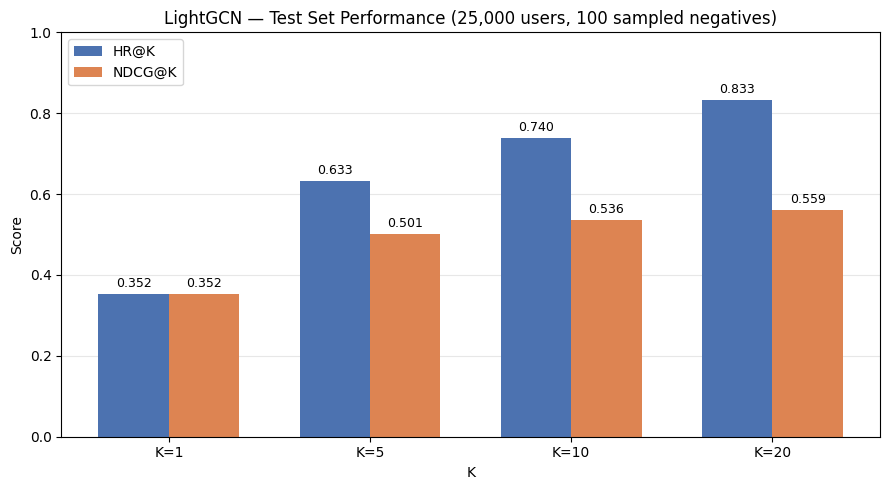

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Pull test metrics for K in [1, 5, 10, 20]
k_values  = [1, 5, 10, 20]
hr_vals   = [sampled_test_metrics[f"HR@{k}"]   for k in k_values]
ndcg_vals = [sampled_test_metrics[f"NDCG@{k}"] for k in k_values]

x = np.arange(len(k_values))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_hr   = ax.bar(x - width/2, hr_vals,   width, label="HR@K",   color="#4C72B0")
bars_ndcg = ax.bar(x + width/2, ndcg_vals, width, label="NDCG@K", color="#DD8452")

# Value labels on top of each bar
for bars in (bars_hr, bars_ndcg):
    for b in bars:
        height = b.get_height()
        ax.annotate(
            f"{height:.3f}",
            xy=(b.get_x() + b.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center", va="bottom", fontsize=9,
        )

ax.set_xlabel("K")
ax.set_ylabel("Score")
ax.set_title(
    f"LightGCN — Test Set Performance "
    f"({sampled_test_metrics['n_users_evaluated']:,} users, "
    f"{sampled_test_metrics['num_negatives']} sampled negatives)"
)
ax.set_xticks(x)
ax.set_xticklabels([f"K={k}" for k in k_values])
ax.set_ylim(0, 1.0)
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 15. Training curves

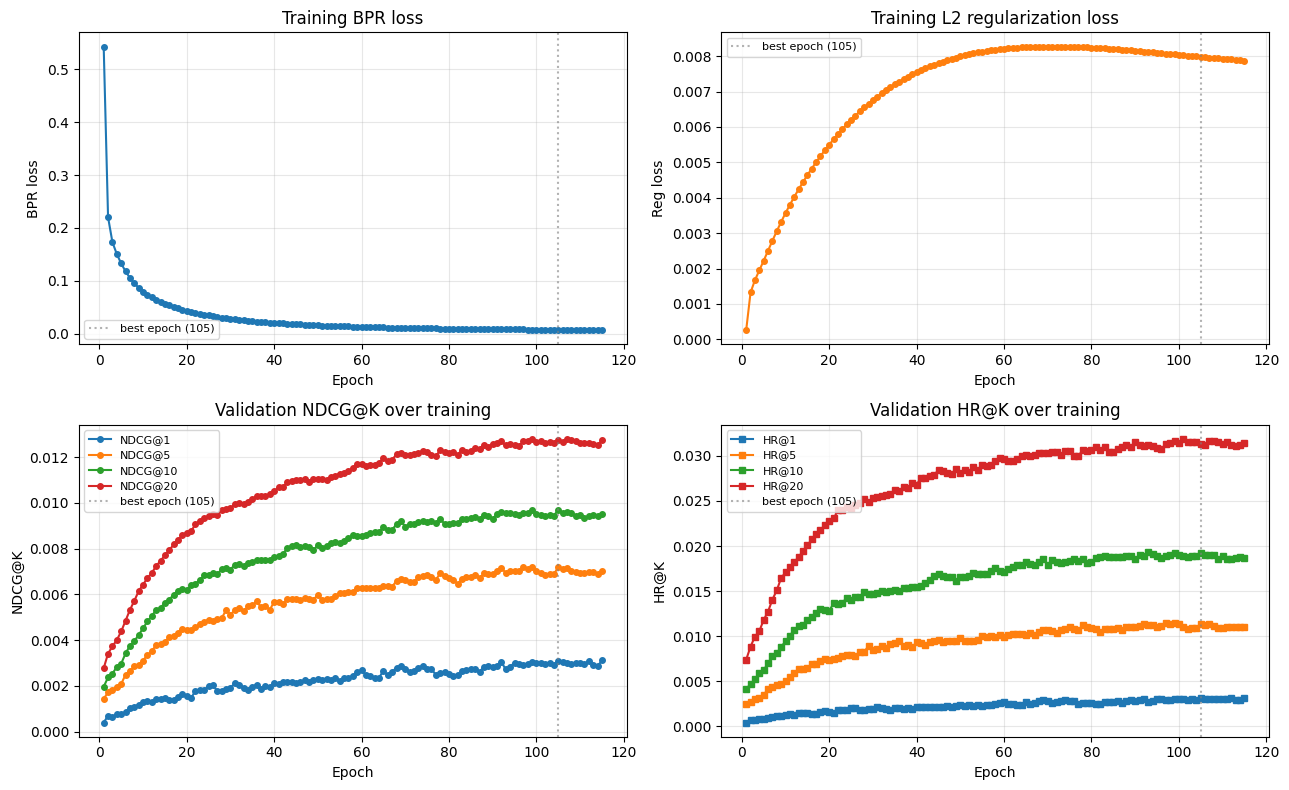

In [16]:
hist_df = pd.DataFrame(history)

# Only keep the K values configured above
PLOT_K_LIST = TOP_K_LIST

# Keep only epochs where validation metrics were actually computed
metric_df = hist_df[hist_df["NDCG@10"].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# ── Panel 1: BPR loss ──
axes[0, 0].plot(
    hist_df["epoch"], hist_df["bpr_loss"],
    marker="o", markersize=4, color="C0"
)
axes[0, 0].axvline(
    best_epoch, linestyle=":", color="gray",
    alpha=0.6, label=f"best epoch ({best_epoch})"
)
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("BPR loss")
axes[0, 0].set_title("Training BPR loss")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3)

# ── Panel 2: Regularization loss ──
axes[0, 1].plot(
    hist_df["epoch"], hist_df["reg_loss"],
    marker="o", markersize=4, color="C1"
)
axes[0, 1].axvline(
    best_epoch, linestyle=":", color="gray",
    alpha=0.6, label=f"best epoch ({best_epoch})"
)
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Reg loss")
axes[0, 1].set_title("Training L2 regularization loss")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.3)

# ── Panel 3: Validation NDCG@K ──
for k in PLOT_K_LIST:
    axes[1, 0].plot(
        metric_df["epoch"], metric_df[f"NDCG@{k}"],
        marker="o", markersize=4, label=f"NDCG@{k}"
    )
axes[1, 0].axvline(
    best_epoch, linestyle=":", color="gray",
    alpha=0.6, label=f"best epoch ({best_epoch})"
)
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("NDCG@K")
axes[1, 0].set_title("Validation NDCG@K over training")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

# ── Panel 4: Validation HR@K ──
for k in PLOT_K_LIST:
    axes[1, 1].plot(
        metric_df["epoch"], metric_df[f"HR@{k}"],
        marker="s", markersize=4, label=f"HR@{k}"
    )
axes[1, 1].axvline(
    best_epoch, linestyle=":", color="gray",
    alpha=0.6, label=f"best epoch ({best_epoch})"
)
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("HR@K")
axes[1, 1].set_title("Validation HR@K over training")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

## 16. Final summary

In [17]:
print("=" * 72)
print("LIGHTGCN SIMPLE RANKING — SUMMARY")
print("=" * 72)
print(f"Model:                LightGCN ({NUM_LAYERS} layers, embed dim {EMBED_DIM})")
print(f"Training objective:   BPR pairwise ranking + L2 regularization")
print(f"Train graph edges:    {len(train_df):,} observed user-item interactions")
print(f"Rankable items:       {len(rankable_items_np):,} train-known hotels")
print(f"Best epoch:           {best_epoch}")
print(f"Primary metric:       {PRIMARY_METRIC}")
print(f"Secondary metric:     {SECONDARY_METRIC}")
print()
print("VALID:")
print(f"  NDCG@10:            {final_valid_metrics['NDCG@10']:.4f}  ({PRIMARY_METRIC})")
print(f"  HR@10:              {final_valid_metrics['HR@10']:.4f}  ({SECONDARY_METRIC})")
print(f"  NDCG@1 = HR@1:      {final_valid_metrics['NDCG@1']:.4f}")
print(f"  NDCG@5 / HR@5:      {final_valid_metrics['NDCG@5']:.4f} / {final_valid_metrics['HR@5']:.4f}")
print(f"  NDCG@20 / HR@20:    {final_valid_metrics['NDCG@20']:.4f} / {final_valid_metrics['HR@20']:.4f}")
print()
print("TEST:")
print(f"  NDCG@10:            {final_test_metrics['NDCG@10']:.4f}  ({PRIMARY_METRIC})")
print(f"  HR@10:              {final_test_metrics['HR@10']:.4f}  ({SECONDARY_METRIC})")
print(f"  NDCG@1 = HR@1:      {final_test_metrics['NDCG@1']:.4f}")
print(f"  NDCG@5 / HR@5:      {final_test_metrics['NDCG@5']:.4f} / {final_test_metrics['HR@5']:.4f}")
print(f"  NDCG@20 / HR@20:    {final_test_metrics['NDCG@20']:.4f} / {final_test_metrics['HR@20']:.4f}")
print()
print("Progression:")
print("  popularity  → non-personalized ranking via damped mean rating")
print("  MF          → personalized embeddings from direct interactions")
print("  LightGCN    → personalized embeddings refined by graph propagation")


LIGHTGCN SIMPLE RANKING — SUMMARY
Model:                LightGCN (2 layers, embed dim 64)
Training objective:   BPR pairwise ranking + L2 regularization
Train graph edges:    16,064,988 observed user-item interactions
Rankable items:       309,395 train-known hotels
Best epoch:           105
Primary metric:       NDCG@10
Secondary metric:     HR@10

VALID:
  NDCG@10:            0.0097  (NDCG@10)
  HR@10:              0.0192  (HR@10)
  NDCG@1 = HR@1:      0.0031
  NDCG@5 / HR@5:      0.0072 / 0.0114
  NDCG@20 / HR@20:    0.0127 / 0.0313

TEST:
  NDCG@10:            0.0087  (NDCG@10)
  HR@10:              0.0174  (HR@10)
  NDCG@1 = HR@1:      0.0025
  NDCG@5 / HR@5:      0.0065 / 0.0106
  NDCG@20 / HR@20:    0.0115 / 0.0286

Progression:
  popularity  → non-personalized ranking via damped mean rating
  MF          → personalized embeddings from direct interactions
  LightGCN    → personalized embeddings refined by graph propagation


## 17. What LightGCN is actually consuming as input

Worth spelling out in detail, because it's the key to the story this notebook tells.

### The literal inputs

1. **An embedding table of shape `[n_nodes, EMBED_DIM]`.** This is the only trainable parameter. Entries `[0, n_users)` are the layer-0 user embeddings; entries `[n_users, n_users + n_items)` are the layer-0 item embeddings. All values start as small random numbers.

2. **The edge index, a `[2, 2·n_interactions]` tensor.** Every train interaction becomes two directed edges (user→item and item→user). This is a sparse encoding of the bipartite graph — it tells propagation which nodes send messages to which.

That's it. No ratings, no timestamps, no user demographics, no item features, no text.

### Why this minimal input is the right choice for this progression

**It's the same input MF uses, plus graph structure.** MF also learns `[n_users × EMBED_DIM]` user embeddings and `[n_items × EMBED_DIM]` item embeddings. The difference is what happens between the embedding lookup and the scoring:

```
MF:       u_emb = E[user];                    score = u_emb · i_emb
LightGCN: u_emb = propagate(E, edges)[user];  score = u_emb · i_emb
```

Where `propagate(E, edges)` is symmetric-normalized neighborhood averaging repeated `NUM_LAYERS` times, then layer-combined. That's the only conceptual difference. The scoring function is identical. Any performance change between MF and LightGCN is attributable to graph propagation alone.

**Graph structure encodes what matters for ranking.** MF treats each (user, item) interaction as an independent supervision signal. LightGCN treats the entire interaction set as a relational structure: if user A and user B both visited hotels X and Y, and user A also visited hotel Z, then after propagation user B's embedding will have been nudged toward hotel Z via the paths B→X→A→Z and B→Y→A→Z. The model learns from higher-order connections that MF can't see.

**Higher-order neighborhoods solve sparsity.** Your interaction matrix is 99.997% sparse — any given user has interacted with a tiny fraction of items. MF can only exploit direct user-item connections. With 3 layers, LightGCN lets each user's embedding incorporate signal from 3-hop neighborhoods. On sparse data this is where most of the collaborative signal lives, which is the theoretical reason graph methods tend to beat MF on datasets like HotelRec.

**Edge existence is more robust than rating values.** Individual ratings are noisy — a user in a bad mood might rate a good hotel a 3 instead of a 4. But the *existence* of an interaction ("this user visited this hotel") is much less noisy. By reducing each interaction to a single edge and letting the graph structure carry the signal, LightGCN sidesteps the rating-noise problem that affects MF's RMSE training.

### Why the eval and training protocols match

Training and eval both treat every observed train interaction as a positive. Evaluation doesn't filter by rating either — the held-out target counts as ground truth regardless of what the user rated it. This symmetry is deliberate: the task is "predict the next hotel the user will visit," and a visit is a visit at both stages.

### The story the three notebooks tell together

- **Popularity**: score items by their damped mean rating. No user modeling at all.
- **MF**: score items by `user_emb · item_emb`, where embeddings are learned from direct interactions only.
- **LightGCN**: score items by `user_emb · item_emb`, where embeddings are additionally refined by graph-propagated signal from higher-order neighborhoods.

Each step adds exactly one concept. Each step is evaluated on identical ground. That's the clean progression.


## 18. What to do next

Once this simple LightGCN version runs and you have the numbers, the next steps in order:

**1. Update the MF and popularity notebooks to use the same sampled users.** Load `lightgcn_valid_eval_users.npy` and `lightgcn_test_eval_users.npy` in those notebooks; evaluate only on those user IDs. This makes the three-way comparison protocol-identical.

**2. Retrain MF with stronger hyperparameters.** Your CV sweep showed `lr=0.01` beats `lr=0.001`. Try `n_factors=50, lr=0.01, reg=0.01, epochs≥10` so MF clearly beats popularity on ranking metrics — which is the logical order needed for the progression story.

**3. Build the comparison table.** Three rows × six columns (HR@{5,10,20} × NDCG@{5,10,20}). If the progression holds, NDCG@10 should increase popularity → MF → LightGCN.

**4. Only after that, consider extensions.** Natural next ideas, roughly by expected impact:
   - LightGCN retriever + metadata-aware reranker (two-stage)
   - Geo-aware LightGCN (geo as graph nodes, not a hard filter)
   - Content-initialized item embeddings
   - Self-supervised contrastive augmentation (SGL-style)

That sequence keeps the project easy to explain:
*simple baseline → personalized baseline → graph baseline → metadata extension.*
